---
title: Multiobjective Optimisation with Pareto Fronts
image: image.png
toc: true
execute: 
  enabled: true
---

When we want to optimize for multiple metrics, we can use a **pareto front** to pull out solutions that are good across multiple dimensions. 

Let's first imagine we're just interested in weighted average travel time, and coverage, and we are trying to work out the best single option to select.

Hospital A gives a weighted average travel time of 30 minutes, with coverage of 40% of people being within 60 minutes. 

Hospital B gives a weighted average travel time of 20 minutes, with coverage of 30% of people being within 60 minutes.

Hospital C gives a weighted average travel time of 40 minutes, with coverage of 50% of people being within 60 minutes. 

Hospital D gives a weighted average travel time of 45 minutes and a coverage of 25%. 

In pareto frontiers, we look at whether a solution is *dominated* by other options. 

Hospital B is not dominated by hospital A, because hospital A has better coverage despite worse weighted average travel time. 

Hospital B is not dominated by hospital C, because hospital C was worse travel time despite better coverage. 

However, hospital D is worse in every respect than the other solutions; this is a *dominated* solution and so can be disregarded from our list. 



Let's first remind ourselves of pareto fronts when just looking at two metrics at a time. 

In [1]:
from lokigi.site import SiteProblem
from lokigi.multiobjective import ParetoMetric

In [2]:
problem = SiteProblem()

problem.add_sites(
    "../../../sample_data/devon_cdcs.csv",
    candidate_id_col="Facility_Name",
    vertical_geometry_col="Latitude",
    horizontal_geometry_col="Longitude",
    required_sites_col="Existing"
    )

problem.add_region_geometry_layer(
    "../../../sample_data/LSOA_Devon_2021_EW_BSC_V4.gpkg",
    common_col="LSOA21NM"
    )

problem.add_travel_matrix(
    travel_matrix_df="../../../sample_data/travel_matrix_car_devon_cdcs.csv",
    source_col="from_id",
    unit="minutes",
    )

problem.add_demand(
    "../../../sample_data/demand_MF_50_84.csv",
    demand_col="Total",
    location_id_col="LSOA 2021 Name"
    )

problem.add_equity_data(
    "../../../sample_data/devon_imd_2025_2021_LSOAs.csv",
    equity_col="Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOA",
    common_col="LSOA name (2021)",
    label="IMD Decile (1 = most deprived)"
    )

Guessed CRS: EPSG:4326 (Values fall within longitude/latitude bounds)


In [3]:
solution = problem.solve(p=6, objectives="p_median", threshold_for_coverage=20)

  0%|          | 0/91 [00:00<?, ?it/s]

In [4]:
solution.show_solutions()

,solution_rank,site_names,site_indices,unselected_site_names,coverage_threshold,weighted_average,unweighted_average,90th_percentile,max,total_cost,...,gap_relative_weighted,avg_lower_third_bins,avg_middle_third_bins,avg_upper_third_bins,inter_tertile_ratio,gap_absolute_description,gap_relative_description,inter_tertile_description,problem_df,additional_site_names
0,1,"[Bideford Community Hospital, NHS Nightingale ...","[0, 1, 2, 3, 8, 12]","[Tiverton - Lowman Way, Okehampton - Exeter Ro...",20,19.07,18.81,38.69,61.18,NaN,...,2.48,15.16,21.78,16.51,0.92,Spread of 14.5 minutes between best and worst ...,Significant Disparity (Worst group travels 148...,Slightly Progressive (Most deprived travel 8% ...,LSOA 2021 Name Bideford Community Hospi...,"[Newton Abbott - Market Walk, Barnstaple - Arc..."
1,2,"[Bideford Community Hospital, NHS Nightingale ...","[0, 1, 2, 3, 5, 12]","[Tiverton - Lowman Way, Crediton - Lords Meado...",20,19.09,19.01,34.43,61.53,NaN,...,2.43,14.74,22.09,17.55,0.84,Spread of 14.1 minutes between best and worst ...,Significant Disparity (Worst group travels 143...,Slightly Progressive (Most deprived travel 16%...,LSOA 2021 Name Bideford Community Hospi...,"[Okehampton - Exeter Road Industrial Estate, B..."
2,3,"[Bideford Community Hospital, NHS Nightingale ...","[0, 1, 2, 3, 9, 12]","[Tiverton - Lowman Way, Okehampton - Exeter Ro...",20,19.20,18.99,38.18,61.53,NaN,...,2.46,15.34,21.77,17.01,0.90,Spread of 14.3 minutes between best and worst ...,Significant Disparity (Worst group travels 146...,Slightly Progressive (Most deprived travel 10%...,LSOA 2021 Name Bideford Community Hospi...,"[Bovey Tracey - Blue Waters, Barnstaple - Arch..."
3,4,"[Bideford Community Hospital, NHS Nightingale ...","[0, 1, 2, 3, 4, 12]","[Okehampton - Exeter Road Industrial Estate, C...",20,19.20,19.08,38.11,61.53,NaN,...,2.56,14.79,22.07,17.22,0.86,Spread of 15.3 minutes between best and worst ...,Significant Disparity (Worst group travels 156...,Slightly Progressive (Most deprived travel 14%...,LSOA 2021 Name Bideford Community Hospi...,"[Tiverton - Lowman Way, Barnstaple - Archwood ..."
4,5,"[Bideford Community Hospital, NHS Nightingale ...","[0, 1, 2, 3, 12, 17]","[Tiverton - Lowman Way, Okehampton - Exeter Ro...",20,19.25,18.98,38.18,61.18,NaN,...,2.76,14.89,21.84,17.28,0.86,Spread of 15.4 minutes between best and worst ...,Significant Disparity (Worst group travels 176...,Slightly Progressive (Most deprived travel 14%...,LSOA 2021 Name Bideford Community Hospi...,"[Barnstaple - Archwood Retail Park, Paignton -..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,87,"[Bideford Community Hospital, NHS Nightingale ...","[0, 1, 2, 3, 6, 16]","[Tiverton - Lowman Way, Okehampton - Exeter Ro...",20,20.19,20.18,38.69,61.53,NaN,...,2.24,15.72,23.61,17.96,0.88,Spread of 14.3 minutes between best and worst ...,Significant Disparity (Worst group travels 124...,Slightly Progressive (Most deprived travel 12%...,LSOA 2021 Name Bideford Community Hospi...,"[Crediton - Lords Meadow, Holsworthy - Underlane]"
87,88,"[Bideford Community Hospital, NHS Nightingale ...","[0, 1, 2, 3, 7, 11]","[Tiverton - Lowman Way, Okehampton - Exeter Ro...",20,20.21,20.12,39.84,61.53,NaN,...,2.32,16.08,23.60,17.14,0.94,Spread of 14.8 minutes between best and worst ...,Significant Disparity (Worst group travels 132...,Slightly Progressive (Most deprived travel 6% ...,LSOA 2021 Name Bideford Community Hospi...,"[South Molton - Pathfields, Exmouth - The Strand]"
88,89,"[Bideford Community Hospital, NHS Nightingale ...","[0, 1, 2, 3, 15, 16]","[Tiverton - Lowman Way, Okehampton - Exeter Ro...",20,20.22,20.15,38.48,61.53,NaN,...,2.21,16.12,23.44,17.43,0.92,Spread of 14.0 minutes between best and worst ...,Significant Disparity (Worst group travels 121...,Slightly Progressive (Most deprived travel 8% ...,LSOA 2021 Name Bideford Community Hospi...,"[Tavistock - Drake Road, Holsworthy - Underlane]"
89,90,"[Bideford Community Hospital

Let's recap all of the column names we have. 

In [5]:
solution.show_solutions_colnames()

Index(['solution_rank', 'site_names', 'site_indices', 'unselected_site_names',
       'coverage_threshold', 'weighted_average', 'unweighted_average',
       '90th_percentile', 'max', 'total_cost',
       'proportion_within_coverage_threshold',
       'proportion_regions_within_coverage_threshold',
       'demand_within_coverage_threshold', 'regions_within_coverage_threshold',
       'weighted_by_equity_group', 'unweighted_by_equity_group',
       'coverage_by_equity_group', 'coverage_regions_by_equity_group',
       'max_cost_by_equity_group', 'gap_absolute_weighted',
       'gap_relative_weighted', 'avg_lower_third_bins',
       'avg_middle_third_bins', 'avg_upper_third_bins', 'inter_tertile_ratio',
       'gap_absolute_description', 'gap_relative_description',
       'inter_tertile_description', 'problem_df', 'additional_site_names'],
      dtype='str')


Let's look at a couple of trade-offs. 

In the plot below, the line indicates the **pareto front** - the non-dominated solutions. 

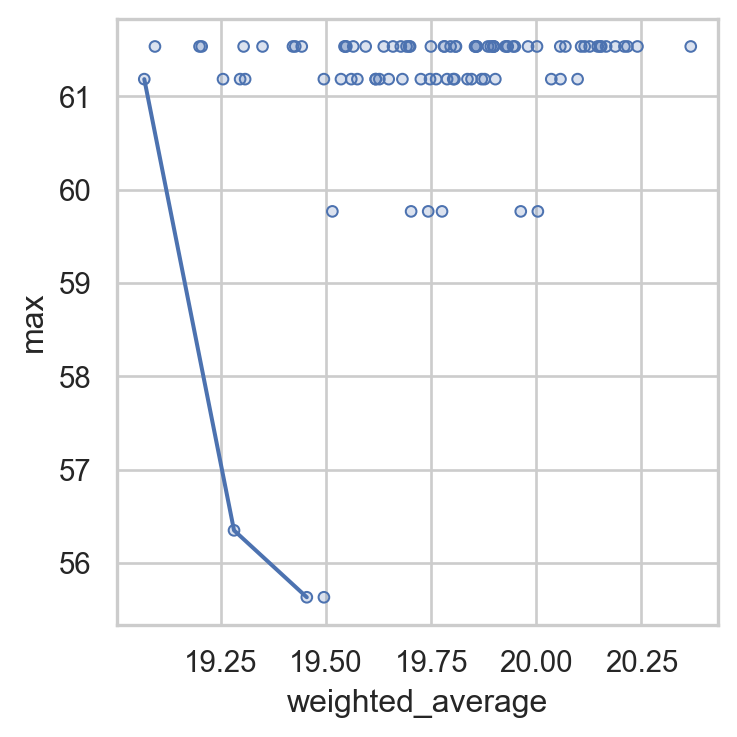

In [6]:
solution.plot_simple_pareto_front_pairs(x_axis="weighted_average", y_axis="max")

We can see that there are three non-dominated solutions joined by this line: 

- Weighted average travel time of 19.45, max travel time of 55.6 minutes
- Weighted average travel time of 19.27 (better), max travel time of 56.4 minutes (worse)
- Weighted average travel time of 19.1 (better again), max travel time of 61.2 minutes (worse again)

We can repeat this for another metric, like weighted average travel time against coverage.

Here, we can see that there is one single best solution in the top left corner - a coverage of 0.62, with a weighted average travel time of 19.07. Therefore, no pareto front is plotted. 

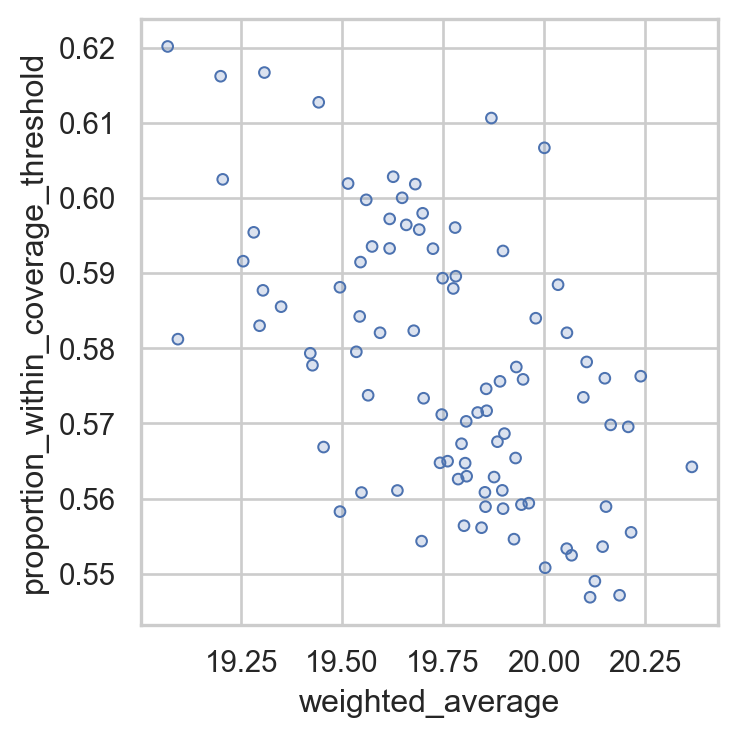

In [7]:
solution.plot_simple_pareto_front_pairs(
    x_axis="weighted_average",
    y_axis="proportion_within_coverage_threshold",
    maxx=False,
    maxy=True
    )

But often we will want to consider more metrics than just two. 

When this is the case, we can use lokigi's ParetoMetric to define a list of metrics we wish to consider. 

In [8]:
metrics = [
        ParetoMetric(column="weighted_average", direction="lower_better",
                     label="weighted average travel time", unit="minutes"),
        ParetoMetric(column="max", direction="lower_better",
                     label="maximum travel time", unit="minutes"),
        ParetoMetric(column="proportion_within_coverage_threshold", direction="higher_better",
                     label="proportion within coverage threshold"),
        ParetoMetric(column="inter_tertile_ratio", direction="closest_to_target", target=1.0,
                     label = "ratio of weighted travel times in IMD 1-3 to IMD 7-10")
        ]

We then pass these metrics in and can see that some new columns have been added to our solutions dataframe, identifying which solutions are considered 'pareto optimal' in any given cases.

In [9]:
solution.compute_pareto_front(
    metrics=metrics
        )

solution.show_solutions()[["solution_rank", "is_pareto_optimal", "dominated_by"]]

,solution_rank,is_pareto_optimal,dominated_by
0,1,True,[]
1,2,False,[1]
2,3,False,[1]
3,4,False,"[1, 3]"
4,5,False,[1]
...,...,...,...
86,87,False,"[1, 3, 6, 7, 8, 9, 10, 13, 15, 16, 17, 18, 19,..."
87,88,False,"[17, 22, 24, 25, 27, 28, 30, 34, 36, 38, 40, 4..."
88,89,False,"[9, 10, 17, 19, 21, 22, 24, 25, 26, 27, 28, 30..."
89,90,False,"[17, 22, 24, 25, 27, 28, 34, 36, 38, 58, 73, 7..."


The pareto_summary() method returns only solutions that are non-dominated. 

In [10]:
solution.pareto_summary()

,solution_rank,weighted_average,max,proportion_within_coverage_threshold,inter_tertile_ratio
0,1,19.067738,61.183334,0.620176,0.918114
1,6,19.281145,56.350000,0.595434,0.922975
2,9,19.307562,61.183334,0.616704,0.938325
3,14,19.454259,55.633335,0.566852,0.867636
4,16,19.494915,55.633335,0.558261,0.904269
5,17,19.515019,59.766666,0.601931,0.998318
6,28,19.626803,61.183334,0.602836,0.950538
7,58,19.870268,61.183334,0.610648,1.021753
8,73,20.001618,61.533333,0.606685,1.001758


By default, it only returns the metrics of interest, but we can opt to return all. 

In [11]:
solution.pareto_summary(return_full_df=True)

,solution_rank,site_names,site_indices,unselected_site_names,coverage_threshold,weighted_average,unweighted_average,90th_percentile,max,total_cost,...,avg_middle_third_bins,avg_upper_third_bins,inter_tertile_ratio,gap_absolute_description,gap_relative_description,inter_tertile_description,problem_df,additional_site_names,is_pareto_optimal,dominated_by
0,1,"[Bideford Community Hospital, NHS Nightingale ...","[0, 1, 2, 3, 8, 12]","[Tiverton - Lowman Way, Okehampton - Exeter Ro...",20,19.067738,18.811545,38.690000,61.183334,NaN,...,21.776667,16.506667,0.918114,Spread of 14.5 minutes between best and worst ...,Significant Disparity (Worst group travels 148...,Slightly Progressive (Most deprived travel 8% ...,LSOA 2021 Name Bideford Community Hospi...,"[Newton Abbott - Market Walk, Barnstaple - Arc...",True,[]
1,6,"[Bideford Community Hospital, NHS Nightingale ...","[0, 1, 2, 3, 5, 8]","[Tiverton - Lowman Way, Crediton - Lords Meado...",20,19.281145,19.176315,36.410000,56.350000,NaN,...,22.093333,16.996667,0.922975,Spread of 12.0 minutes between best and worst ...,Significant Disparity (Worst group travels 104...,Slightly Progressive (Most deprived travel 8% ...,LSOA 2021 Name Bideford Community Hospi...,"[Okehampton - Exeter Road Industrial Estate, N...",True,[]
2,9,"[Bideford Community Hospital, NHS Nightingale ...","[0, 1, 2, 3, 4, 8]","[Okehampton - Exeter Road Industrial Estate, C...",20,19.307562,19.178669,40.630000,61.183334,NaN,...,22.020000,16.660000,0.938325,Spread of 13.2 minutes between best and worst ...,Significant Disparity (Worst group travels 114...,Slightly Progressive (Most deprived travel 6% ...,LSOA 2021 Name Bideford Community Hospi...,"[Tiverton - Lowman Way, Newton Abbott - Market...",True,[]
3,14,"[Bideford Community Hospital, NHS Nightingale ...","[0, 1, 2, 3, 5, 17]","[Tiverton - Lowman Way, Crediton - Lords Meado...",20,19.454259,19.327115,35.893332,55.633335,NaN,...,22.123333,17.766667,0.867636,Spread of 12.7 minutes between best and worst ...,Significant Disparity (Worst group travels 122...,Slightly Progressive (Most deprived travel 13%...,LSOA 2021 Name Bideford Community Hospi...,"[Okehampton - Exeter Road Industrial Estate, P...",True,[]
4,16,"[Bideford Community Hospital, NHS Nightingale ...","[0, 1, 2, 3, 5, 14]","[Tiverton - Lowman Way, Crediton - Lords Meado...",20,19.494915,19.554390,34.653334,55.633335,NaN,...,21.250000,18.036667,0.904269,Spread of 11.4 minutes between best and worst ...,Significant Disparity (Worst group travels 98%...,Slightly Progressive (Most deprived travel 10%...,LSOA 2021 Name Bideford Community Hospi...,"[Okehampton - Exeter Road Industrial Estate, K...",True,[]
5,17,"[Bideford Community Hospital, NHS Nightingale ...","[0, 1, 2, 3, 8, 15]","[Tiverton - Lowman Way, Okehampton - Exeter Ro...",20,19.515019,19.324166,39.430001,59.766666,NaN,...,22.076667,16.350000,0.998318,Spread of 12.4 minutes between best and worst ...,Significant Disparity (Worst group travels 107...,Balanced (Macro travel times are broadly equal),LSOA 2021 Name Bideford Community Hospi...,"[Newton Abbott - Market Walk, Tavistock - Drak...",True,[]
6,28,"[Bideford Community Hospital, NHS Nightingale ...","[0, 1, 2, 3, 8, 17]","[Tiverton - Lowman Way, Okehampton - Exeter Ro...",20,19.626803,19.301166,41.746667,61.183334,NaN,...,22.173333,16.730000,0.950538,Spread of 14.7 minutes between best and worst ...,Significant Disparity (Worst group travels 141...,Balanced (Macro travel times are broadly equal),LSOA 2021 Name Bideford Community Hospi...,"[Newton Abbott - Market Walk, Paignton - Hyde ...",True,[]
7,58,"[Bideford Community Hospital, NHS Nightingale ...","[0, 1, 2, 3, 8, 11]","[Tiverton - Lowman Way, Okehampton - Exeter Ro...",20,19.870268,19.635940,42.073333,61.183334,NaN,...,22.710000,16.090000,1.021753,Spread of 13.6 minutes between best and worst ...,Significant Disparity (Worst group travels 118...,Balanced (Macro travel times are broadly equal),LSOA 2021 Name Bideford Community Hospi...,"[New

We can also look at the tradeoffs of each solution compared to the winner for weighted average. 

In [12]:
solution.describe_tradeoffs()

['Solution 6 vs solution 1: costs weighted average travel time by 0.21; improves maximum travel time by 4.83; costs proportion within coverage threshold by 0.02; improves ratio of weighted travel times in imd 1-3 to imd 7-10 by 0.00',
 'Solution 9 vs solution 1: costs weighted average travel time by 0.24; costs proportion within coverage threshold by 0.00; improves ratio of weighted travel times in imd 1-3 to imd 7-10 by 0.02',
 'Solution 14 vs solution 1: costs weighted average travel time by 0.39; improves maximum travel time by 5.55; costs proportion within coverage threshold by 0.05; costs ratio of weighted travel times in imd 1-3 to imd 7-10 by 0.05',
 'Solution 16 vs solution 1: costs weighted average travel time by 0.43; improves maximum travel time by 5.55; costs proportion within coverage threshold by 0.06; costs ratio of weighted travel times in imd 1-3 to imd 7-10 by 0.01',
 'Solution 17 vs solution 1: costs weighted average travel time by 0.45; improves maximum travel time 

We can opt for a more stakeholder-focussed output, which is returned as a list of markdown strings for easy inclusion in a Quarto report or Streamlit frontend. 

In [13]:
solution.describe_tradeoffs_for_stakeholders()

['We found 9 genuinely different options -- each one is the best choice on at least one measure, so no single option wins on everything. The trade-offs are between weighted average travel time, maximum travel time, proportion within coverage threshold, ratio of weighted travel times in imd 1-3 to imd 7-10.',
 '**Option 6** (compared with Option 1)\n- Gains: maximum travel time improves by 4.8 minutes; ratio of weighted travel times in IMD 1-3 to IMD 7-10 improves by 0.0\n- Costs: weighted average travel time is 0.2 minutes worse; proportion within coverage threshold is 0.0 worse',
 '**Option 9** (compared with Option 1)\n- Gains: ratio of weighted travel times in IMD 1-3 to IMD 7-10 improves by 0.0\n- Costs: weighted average travel time is 0.2 minutes worse; proportion within coverage threshold is 0.0 worse',
 '**Option 14** (compared with Option 1)\n- Gains: maximum travel time improves by 5.5 minutes\n- Costs: weighted average travel time is 0.4 minutes worse; proportion within cover

## Advanced Pareto Plots

When we are looking at more than 2 metrics, the pareto plots from before stop being so useful for interpretation. 

Instead, we can use plot_pareto_summary. 

This plots every non-dominated solution as a coloured line. Grey lines indicate other solutions to give context for the range of values of each metric. 

Metrics are scaled in such a way that values further up the axis will always be better, even if that means flipping the direction. 

For example, we have the shortest travel time (a smaller number) at the top, but the best coverage (a higher number) both appearing as the points at the top of the graph. So to interpret, we can just read it as values further up the y axis being better, and values further down being worse. This is also true for values that are aiming for a target - for example, for the IMD travel ratio, in this case we want it to be close to 1 (i.e. minimal difference between travel times across the upper and lower three deciles), so the values at the top are those that are closest to 1, and the values further down are those that are higher or lower than 1, with the direction being shown in the labels. 

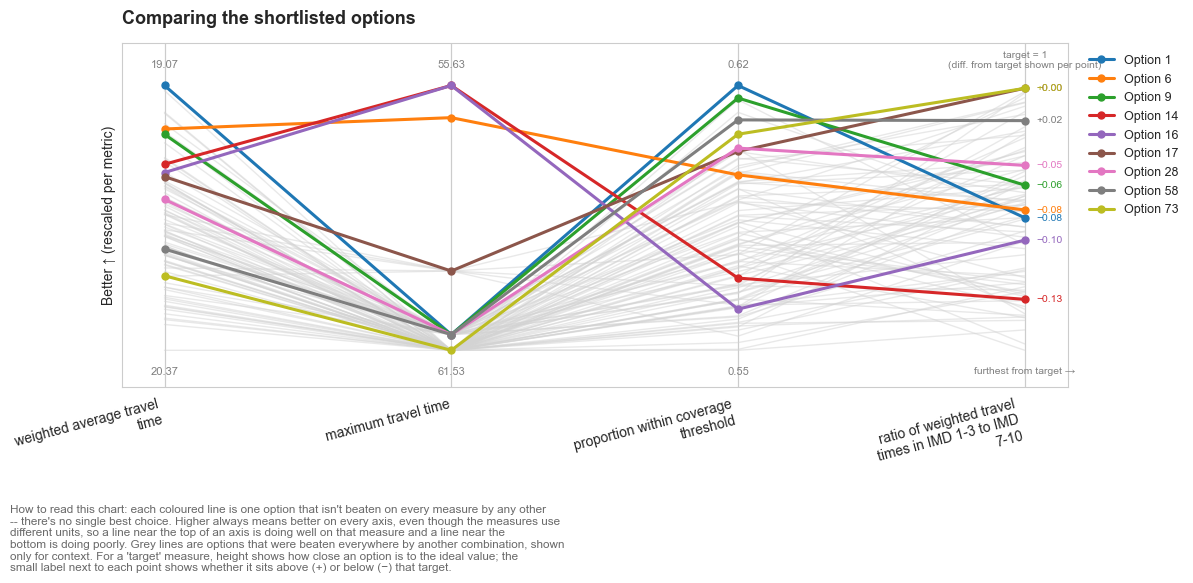

In [14]:
solution.plot_pareto_summary(width_multiplier=3);

We can also use faceted plots to help investigate solutions in more detail. This can help us to understand the tradeoffs in more detail. 

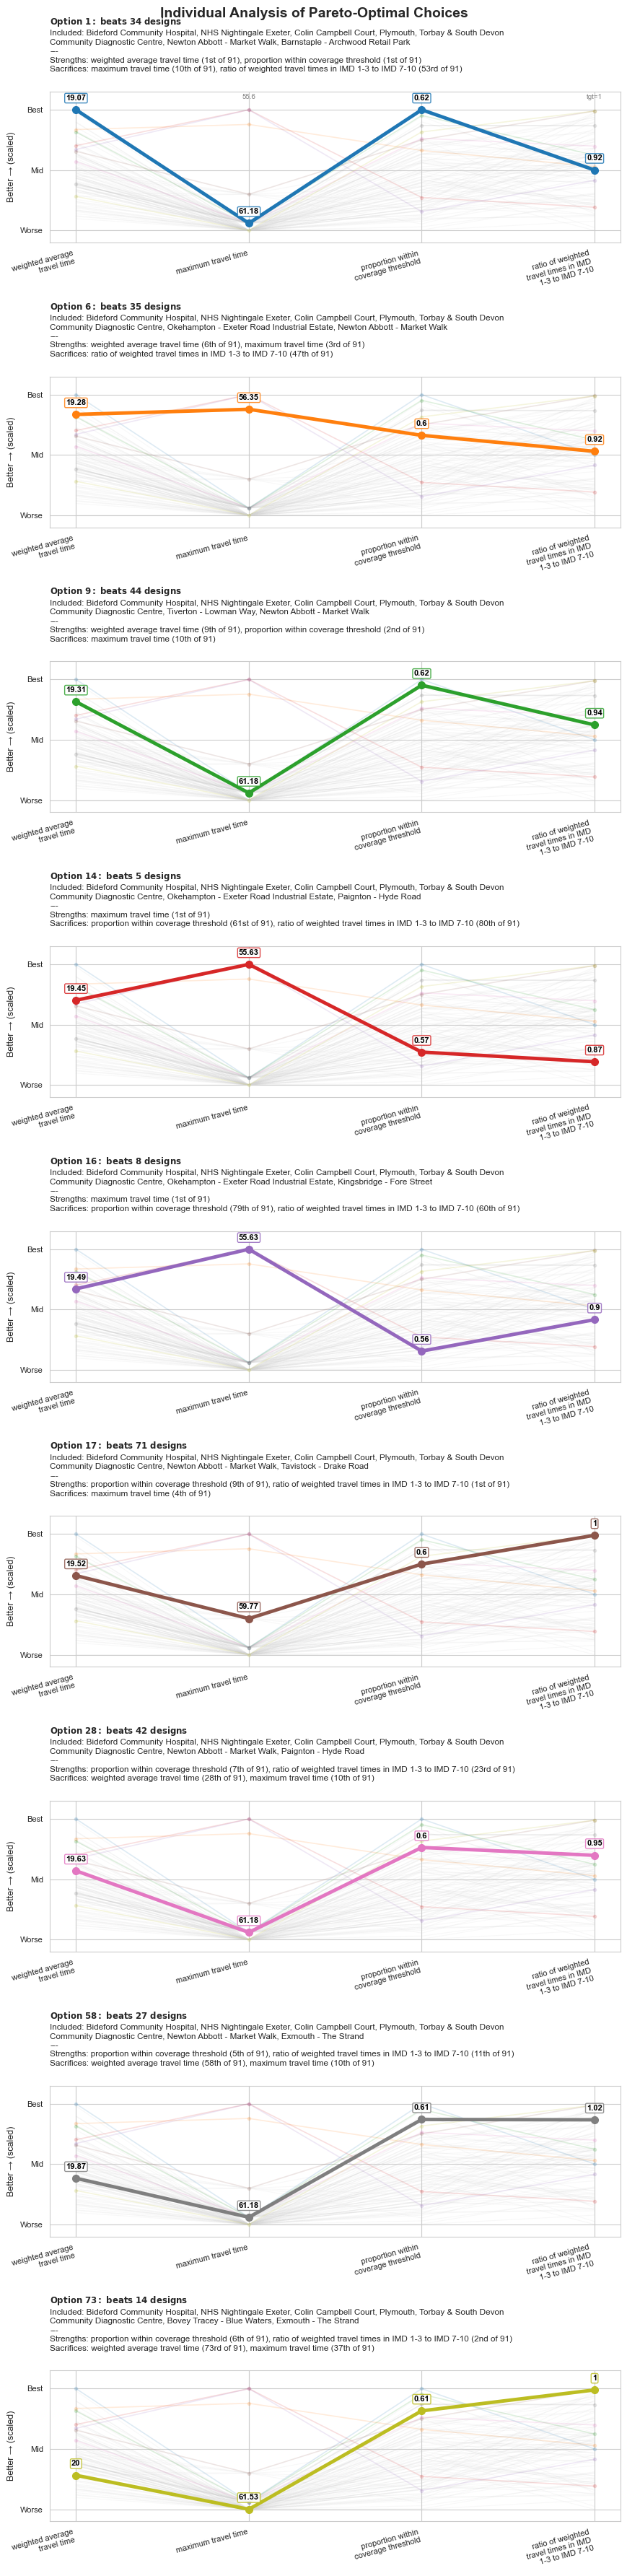

In [15]:
solution.plot_pareto_facets();

Both of the plots above label each option only as "Option 1", "Option 2", etc. `diff_against` adds a compact site-name diff to those labels, so it's immediately clear what actually changes between trade-off options rather than just how they score. This problem has `Existing` sites flagged via `required_sites_col`, so `diff_against="default"` compares each option against those -- "what's new beyond what we already have".

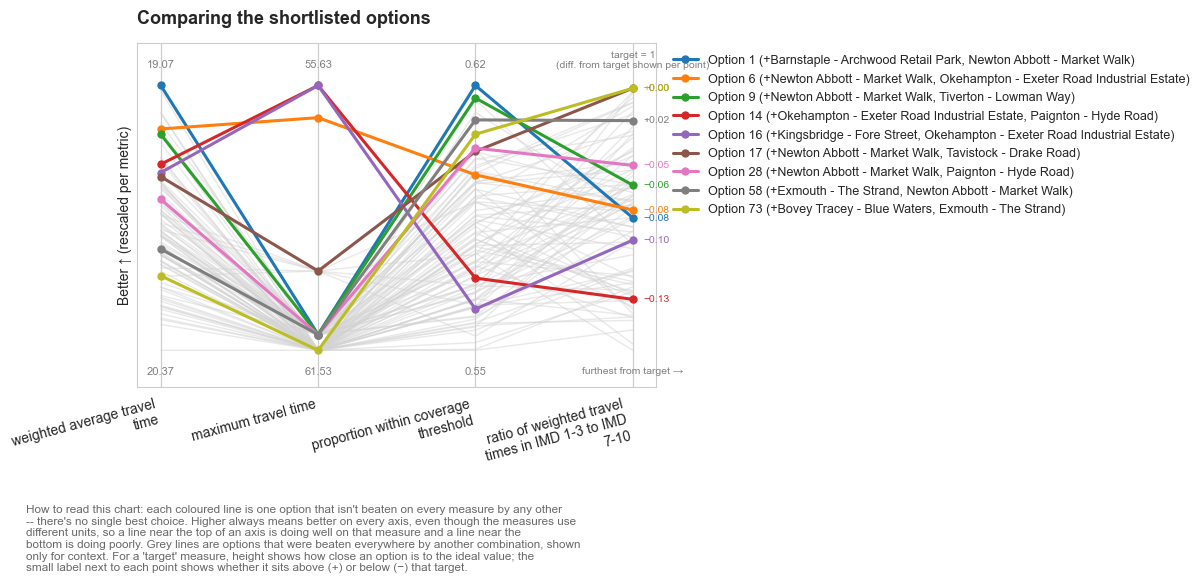

In [16]:
solution.plot_pareto_summary(width_multiplier=3, diff_against="default");

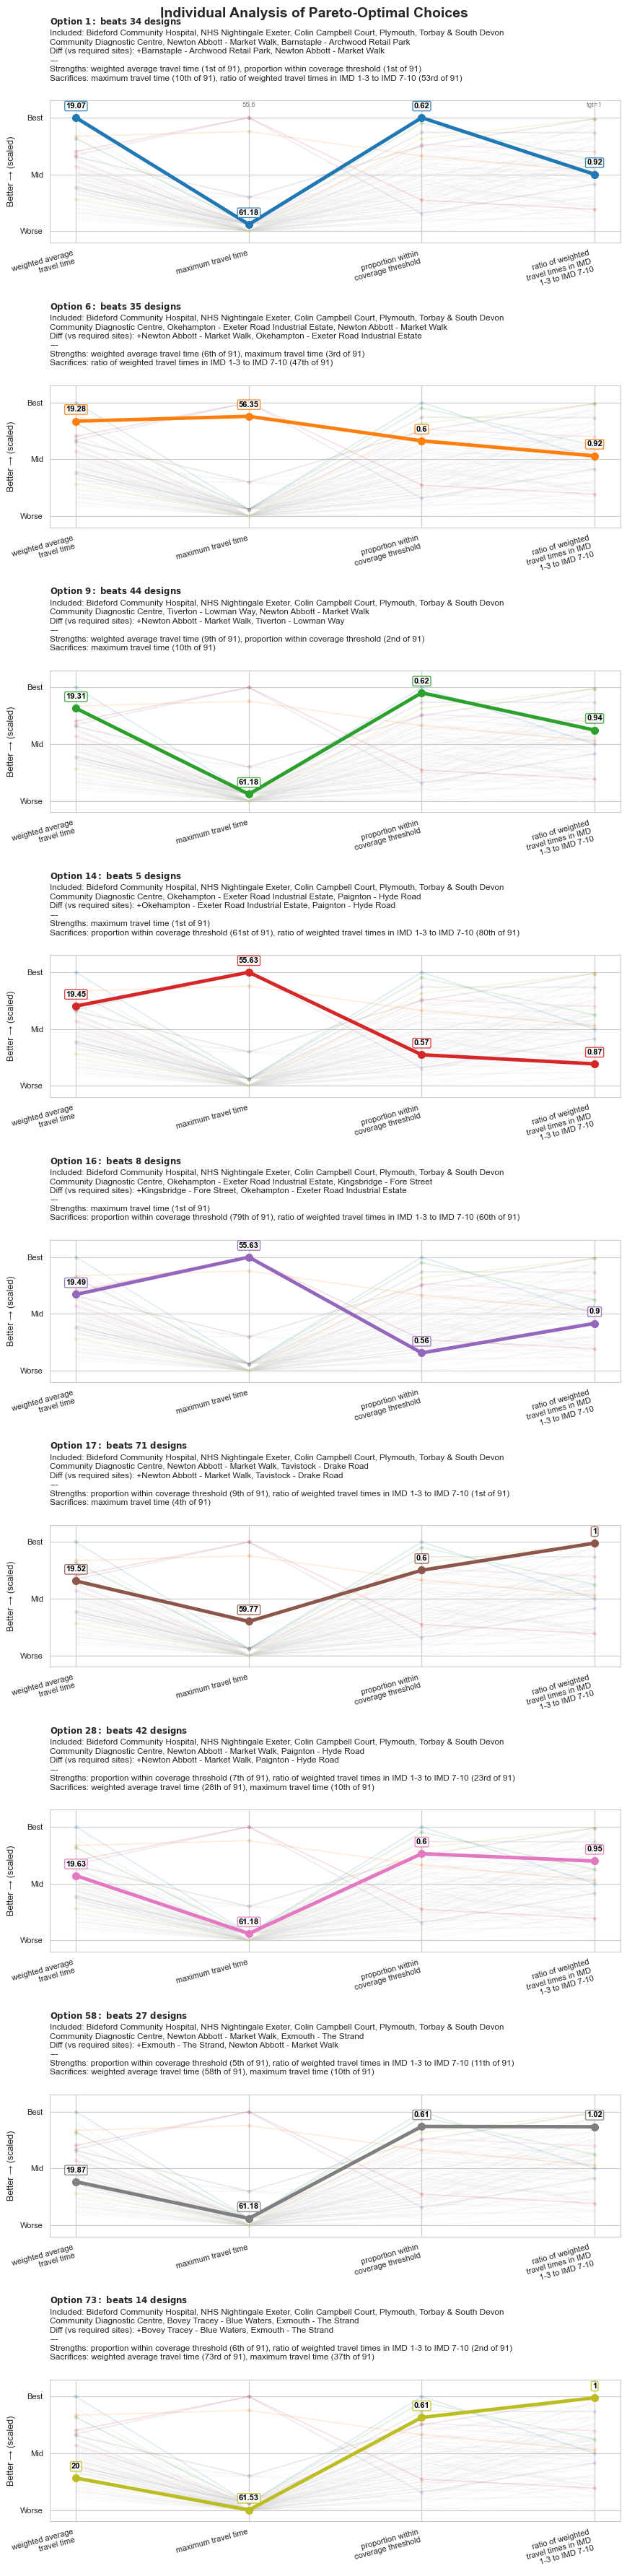

In [17]:
solution.plot_pareto_facets(diff_against="default");

## Adjusting metrics

Let's imagine that rather than wanting to make the inter_tertile ratio as equal as possible, we instead want to prioritise access in the most deprived areas. We simply change the direction to lower_better.  

In [18]:
metrics = [
        ParetoMetric(column="weighted_average", direction="lower_better",
                     label="weighted average travel time", unit="minutes"),
        ParetoMetric(column="max", direction="lower_better",
                     label="maximum travel time", unit="minutes"),
        ParetoMetric(column="proportion_within_coverage_threshold", direction="higher_better",
                     label="proportion within coverage threshold"),
        ParetoMetric(column="inter_tertile_ratio", direction="lower_better",
                     label = "ratio of weighted travel times in IMD 1-3 to IMD 7-10"),
        # ParetoMetric(column="avg_lower_third_bins", direction="lower_better",
        #              label = "Weighted travel times in IMD 1-3")
        ]

Then we can just recompute our pareto front, which will overwrite the relevant flags in the solution dataframe.

In [19]:
solution.compute_pareto_front(
    metrics=metrics
        )

Then we can recreate any required plots. 

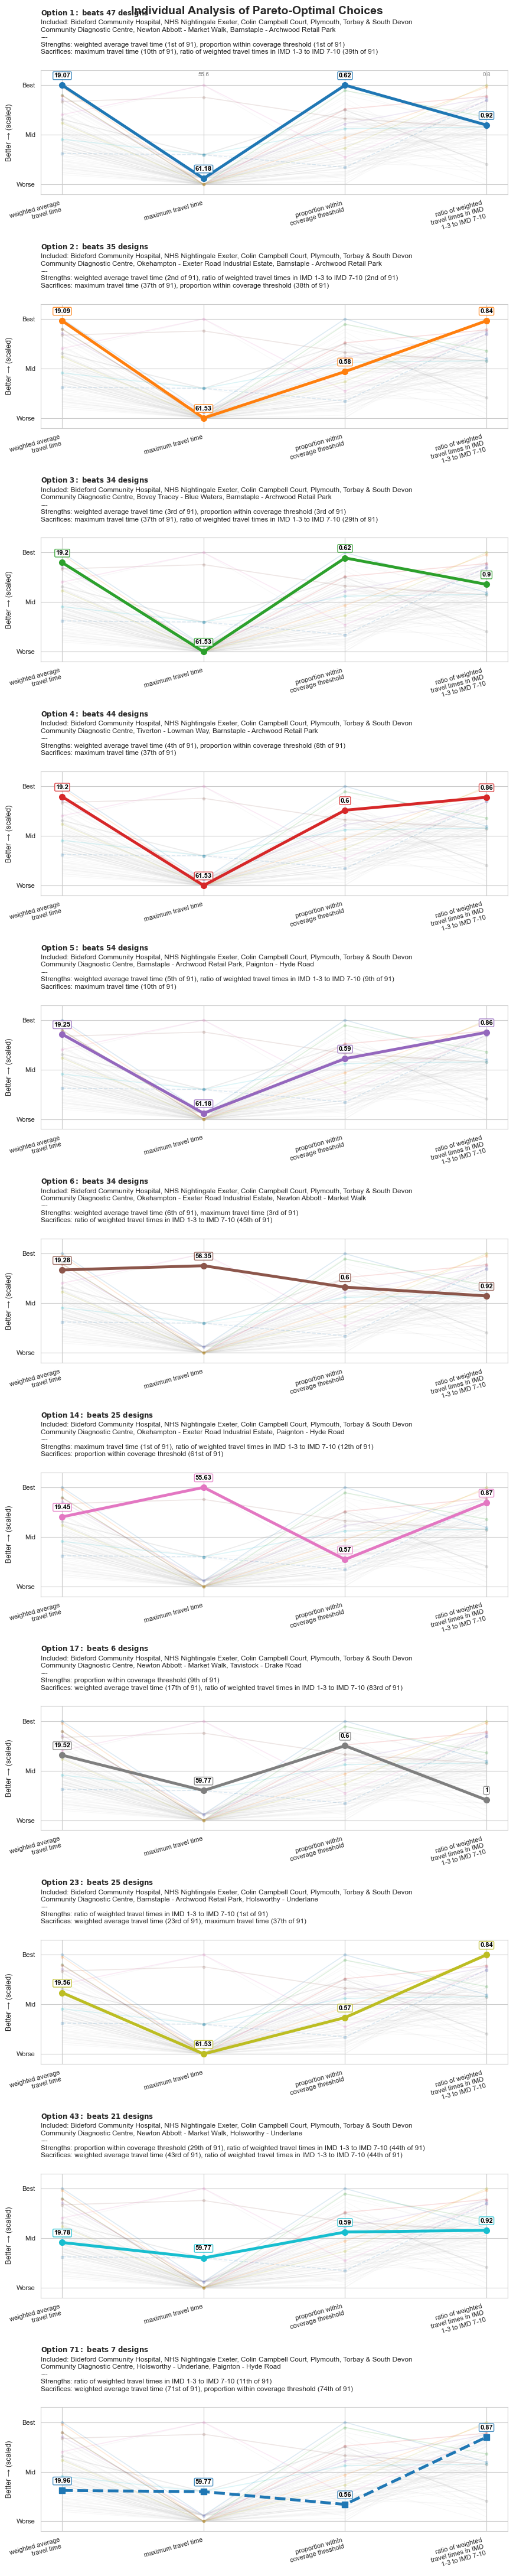

In [20]:
solution.plot_pareto_facets();

In [21]:
solution.pareto_summary(return_full_df=True)[[
    "solution_rank", "inter_tertile_ratio", "inter_tertile_ratio",
    "avg_lower_third_bins", "avg_upper_third_bins"
    ]].round(2)

,solution_rank,inter_tertile_ratio,inter_tertile_ratio,avg_lower_third_bins,avg_upper_third_bins
0,1,0.92,0.92,15.16,16.51
1,2,0.84,0.84,14.74,17.55
2,3,0.90,0.90,15.34,17.01
3,4,0.86,0.86,14.79,17.22
4,5,0.86,0.86,14.89,17.28
5,6,0.92,0.92,15.69,17.00
6,14,0.87,0.87,15.42,17.77
7,17,1.00,1.00,16.32,16.35
8,23,0.84,0.84,14.71,17.60
9,43,0.92,0.92,15.71,17.04
